<a href="https://colab.research.google.com/github/Divyansh-it19/24IT3019_DIVYANSH/blob/main/24IT3019_DIVYANSH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK-1 PROBLEM-1:

In [22]:
!pip install tensorflow numpy pandas matplotlib
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random
import os

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

print("Seeds set to 42")

print("\nPackage Versions:")
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)  # FIXED LINE

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU is available")
    print("Number of GPUs:", len(gpus))
else:
    print("\nNo GPU found")

    # CPU is slower because it has fewer cores and is not optimized for parallel operations.
    # GPU has many cores and can do matrix operations much faster.
    # On GPU machine, I would use GPU acceleration to train models faster.

Seeds set to 42

Package Versions:
TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

GPU is available
Number of GPUs: 1


Why CPU training is slower and what to do on GPU:

CPU is slower because it has fewer cores and is not designed for parallel operations. Deep learning needs many matrix calculations which are faster on GPU. GPU has many cores and can do these calculations quickly. On a GPU machine, we use GPU acceleration to train models faster.

TASK-1 PROBLEM-2

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
MNIST train shape: (60000, 28, 28)
MNIST test shape: (10000, 28, 28)
CIFAR10 train shape: (50000, 32, 32, 3)
CIFAR10 test shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min: 0 max: 255

CIFAR10 dtype: uint8
CIFAR10 min: 0 max: 255

MNIST samples per class:
Class 0 : 5923
Class 1 : 6742
Class 2 : 5958
Class 3 : 6131
Class 4 : 5842
Class 5 : 5421
Class 6 : 5918
Class 7 : 6265
Class 8 : 5851
Class 9 : 5949


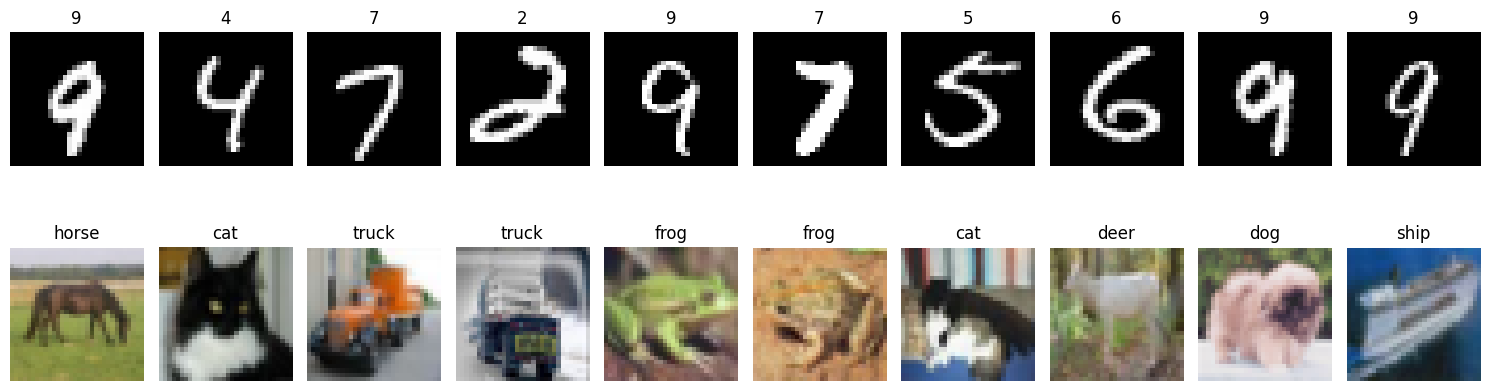

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Load datasets
(xm_train, ym_train), (xm_test, ym_test) = tf.keras.datasets.mnist.load_data()
(xc_train, yc_train), (xc_test, yc_test) = tf.keras.datasets.cifar10.load_data()

# (a) Shapes
print("MNIST train shape:", xm_train.shape)
print("MNIST test shape:", xm_test.shape)

print("CIFAR10 train shape:", xc_train.shape)
print("CIFAR10 test shape:", xc_test.shape)

# (b) Data type and range
print("\nMNIST dtype:", xm_train.dtype)
print("MNIST min:", xm_train.min(), "max:", xm_train.max())

print("\nCIFAR10 dtype:", xc_train.dtype)
print("CIFAR10 min:", xc_train.min(), "max:", xc_train.max())

# (c) Samples per class in MNIST
counts = np.bincount(ym_train)

print("\nMNIST samples per class:")
for i in range(len(counts)):
    print("Class", i, ":", counts[i])

# Plot images
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(15,5))

# MNIST row
for i in range(10):
    idx = random.randint(0, len(xm_train)-1)
    plt.subplot(2,10,i+1)
    plt.imshow(xm_train[idx], cmap='gray')
    plt.title(ym_train[idx])
    plt.axis('off')

# CIFAR row
for i in range(10):
    idx = random.randint(0, len(xc_train)-1)
    plt.subplot(2,10,i+11)
    plt.imshow(xc_train[idx])
    plt.title(class_names[yc_train[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

Answers

(a) Shapes:
MNIST train: (60000, 28, 28), test: (10000, 28, 28)
CIFAR-10 train: (50000, 32, 32, 3), test: (10000, 32, 32, 3)

(b) Data type and range:
Both datasets use uint8. Values range from 0 to 255.

(c) Samples per class (MNIST):
Each class has around 6000 samples. Dataset is approximately balanced.

TASK-1 PROBLEM-3

In [3]:
import tensorflow as tf
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Before processing:")
print("Shape:", x_train.shape)
print("Sample values:", x_train[0][0][:5])

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("\nAfter normalization:")
print("Min:", x_train.min(), "Max:", x_train.max())
print("Sample values:", x_train[0][0][:5])

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("\nAfter reshape:")
print("Shape:", x_train.shape)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("\nAfter one-hot encoding:")
print("Shape:", y_train.shape)
print("Sample label:", y_train[0])

Before processing:
Shape: (60000, 28, 28)
Sample values: [0 0 0 0 0]

After normalization:
Min: 0.0 Max: 1.0
Sample values: [0. 0. 0. 0. 0.]

After reshape:
Shape: (60000, 28, 28, 1)

After one-hot encoding:
Shape: (60000, 10)
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Answer

Pixel values are converted to range 0 to 1 by dividing by 255.
Images are reshaped to add channel dimension.
Labels are converted into one-hot vectors of length 10.

TASK-1 PROBLEM-4

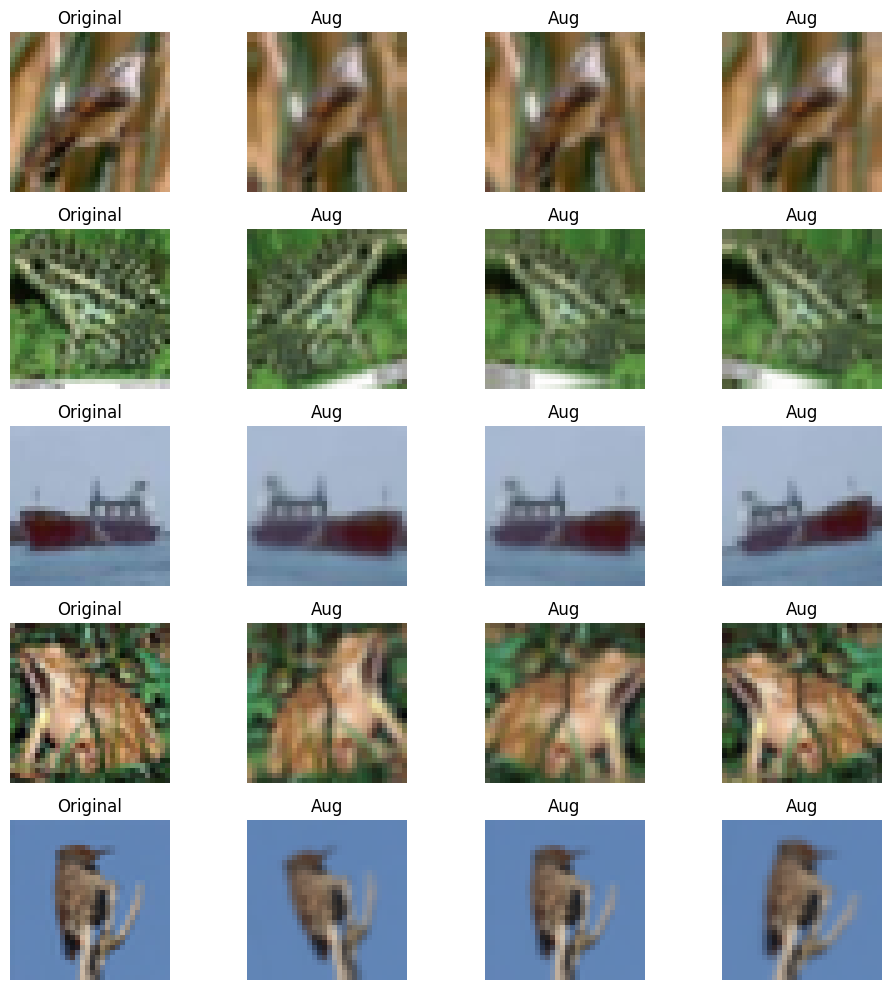

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

plt.figure(figsize=(10,10))

for i in range(5):
    idx = random.randint(0, len(x_train)-1)
    img = x_train[idx]

    plt.subplot(5,4,4*i+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    for j in range(3):
        aug_img = data_aug(tf.expand_dims(img, 0))
        aug_img = tf.squeeze(aug_img)

        plt.subplot(5,4,4*i+j+2)
        plt.imshow(aug_img)
        plt.title("Aug")
        plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Answer

Augmentation is applied only on training data to help the model learn better and generalize.
Validation and test data should remain unchanged to give a correct and fair evaluation of model performance.

Q1 Answer

The channel dimension (C) represents the number of feature maps or color channels.

For a greyscale image, C = 1 (only intensity values)

For an RGB image, C = 3 (Red, Green, Blue channels)

So each channel stores different information about the image.

Q2 Answer

1) Batch loading (mini-batches)

Load small batches of images instead of the full dataset.

This reduces memory usage.

2) Data generators / streaming (tf.data)

Load images from disk only when needed instead of storing all in RAM.

This prevents memory overflow.

Q3 Answer

This is wrong because it causes data leakage.

The test set should not be used to compute statistics.

Mean and standard deviation must be computed only from the training set.

Otherwise, the model indirectly gets information from test data, leading to unfair evaluation.

TASK-2 PROBLEM-1

In [5]:
import numpy as np

def conv2d(img, ker, s, p):
    h, w = img.shape
    kh, kw = ker.shape

    img_p = np.pad(img, ((p,p),(p,p)), mode='constant')

    oh = (h - kh + 2*p)//s + 1
    ow = (w - kw + 2*p)//s + 1

    out = np.zeros((oh, ow))

    for i in range(oh):
        for j in range(ow):
            patch = img_p[i*s:i*s+kh, j*s:j*s+kw]
            out[i,j] = np.sum(patch * ker)

    return out

img = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

ker = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

out = conv2d(img, ker, 1, 0)

print("Output:")
print(out)

print("\nOutput shape:", out.shape)

Output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape: (3, 3)


Answer

Output shape formula:
Output size = (N - F + 2P)/S + 1

Here N=5, F=3, P=0, S=1
So output = (5 - 3 + 0)/1 + 1 = 3

Final shape = (3, 3)

TASK-2 PROBLEM-2

(a)
Formula:
Output = (N - F + 2P) / S + 1
= (28 - 5 + 0) / 1 + 1
= 23 + 1
= 24

Final size: 24 × 24

(b)

= (28 - 3 + 2×1) / 1 + 1
= (28 - 3 + 2) + 1
= 27 + 1
= 28

Final size: 28 × 28

(c)
= (32 - 3 + 0) / 2 + 1
= 29 / 2 + 1
= 14.5 + 1

We take floor → 14

So = 14 + 1 = 15

Final size: 15 × 15

(d)

First layer:
= (32 - 3 + 2×1) / 1 + 1
= 32

Output = 32 × 32

Second layer:
= (32 - 3 + 0) / 1 + 1
= 29 + 1
= 30

Final size: 30 × 30

TASK-2 PROBLEM-3

In [6]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)),
    tf.keras.layers.AveragePooling2D((2,2), strides=2),

    tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
    tf.keras.layers.AveragePooling2D((2,2), strides=2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(120, activation='tanh'),
    tf.keras.layers.Dense(84, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Answers

(a) Total parameters:
From model.summary(), total parameters = 44,426

(b) First Conv2D layer parameters:

Formula:
(K × K × C_in + 1) × C_out

= (5 × 5 × 1 + 1) × 6
= (25 + 1) × 6
= 26 × 6
= 156 parameters

(c) AvgPooling vs MaxPooling:

AvgPooling takes average of values, so it keeps smooth information.
MaxPooling takes maximum value, so it keeps strong features.

Today MaxPooling is preferred because it captures important features better.

TASK-2 PROBLEM-4

 Answer

Architecture Diagram:

Input (32x32x3)
→ Conv(32) → BN → ReLU → MaxPool
→ Conv(64) → BN → ReLU → MaxPool
→ Conv(128) → BN → ReLU → MaxPool
→ GlobalAvgPool
→ Dense(128) → Dropout
→ Dense(10)

Design Rationale:

I used 3 convolution blocks to gradually extract features from simple to complex.
BatchNorm helps training stability and faster convergence.
Pooling reduces size and computation.
Dropout is used to reduce overfitting.

In [7]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

ANALYSIS AND REFLECTION:
Q1 Answer
For one 5×5 Conv layer:
Parameters = (5×5×C + 1) × F
= (25C + 1)F

For two 3×3 Conv layers:
Each layer: (3×3×C + 1) × F = (9C + 1)F
Total = 2 × (9C + 1)F = (18C + 2)F

Since 18C < 25C, two 3×3 layers use fewer parameters.

Other advantages:

More non-linearity (better learning)
Deeper network gives better feature extraction

Q2 Answer

Batch Normalisation normalizes the output of a layer to make training stable.

It is usually placed before activation.

Benefits:

Faster training
Reduces overfitting
Helps stable gradients

Q3 Answer
GlobalAveragePooling takes average of each feature map, so it converts H×W×C into 1×1×C.
It reduces parameters and keeps important information.

If we use Flatten:

Parameter count increases a lot
Model may overfit
Spatial structure is lost directly into dense layer

TASK-3 PROBLEM-1

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7399 - loss: 0.9664 - val_accuracy: 0.8940 - val_loss: 0.4110
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8862 - loss: 0.4064 - val_accuracy: 0.9215 - val_loss: 0.2910
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9072 - loss: 0.3238 - val_accuracy: 0.9335 - val_loss: 0.2400
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9201 - loss: 0.2761 - val_accuracy: 0.9428 - val_loss: 0.2056
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9302 - loss: 0.2398 - val_accuracy: 0.9523 - val_loss: 0.1787
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9390 - loss: 0.2099 - val_accuracy: 0.9595 - val_loss: 0.1568
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9468 - loss: 0.1848 - val_accuracy: 0.9638 - val_loss: 0.1388
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9522 - loss: 0.1637 - val_accuracy: 0.

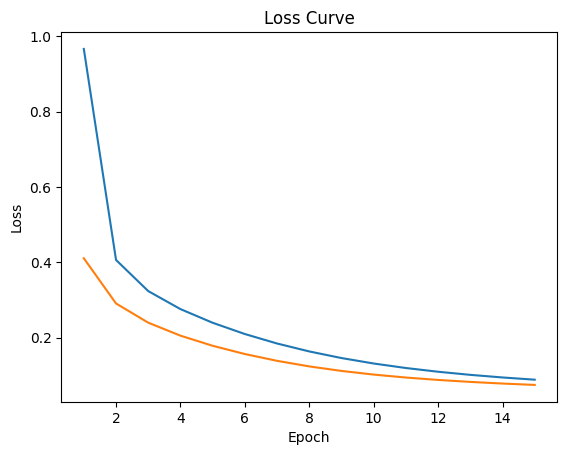

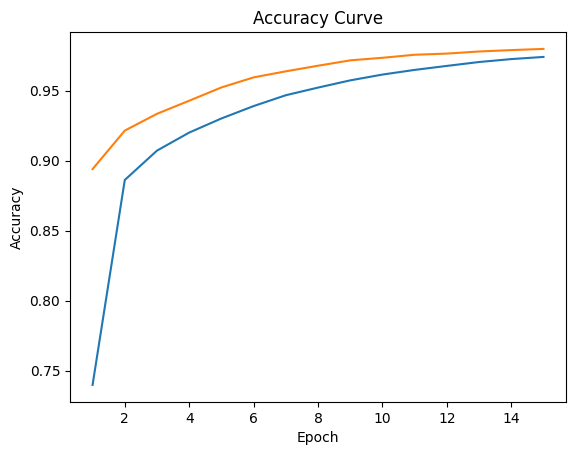

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
    tf.keras.layers.AveragePooling2D((2,2),strides=2),

    tf.keras.layers.Conv2D(16,(5,5),activation='tanh'),
    tf.keras.layers.AveragePooling2D((2,2),strides=2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(120,activation='tanh'),
    tf.keras.layers.Dense(84,activation='tanh'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)

loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1,16)

overfit_epoch = None
for i in range(1,15):
    if val_loss[i] > val_loss[i-1]:
        overfit_epoch = i+1
        break

plt.figure()
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)

if overfit_epoch:
    plt.axvline(overfit_epoch)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.savefig("lenet_sgd_curves.png")
plt.show()

plt.figure()
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)

if overfit_epoch:
    plt.axvline(overfit_epoch)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.savefig("lenet_sgd_curves.png")
plt.show()

 Answers

(c) Overfitting:
Overfitting starts when validation loss increases while training loss decreases.
The first such epoch is the overfitting point (see marked line in graph).

(d) Final Test Accuracy:
0.9764

TASK-3 PROBLEM-2

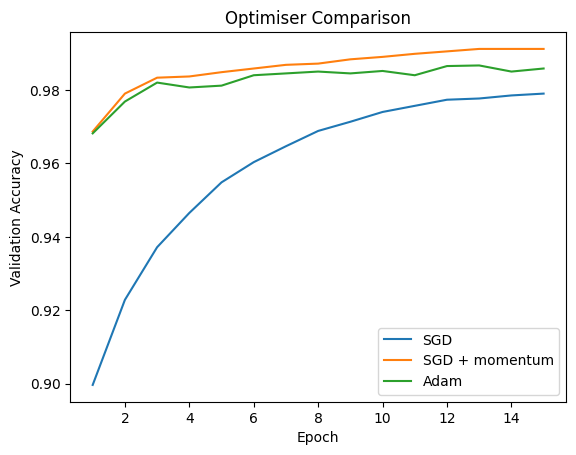

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32')/255.0
x_train = x_train.reshape(-1,28,28,1)
y_train = tf.keras.utils.to_categorical(y_train,10)

def make_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(6,(5,5),activation='tanh',input_shape=(28,28,1)),
        tf.keras.layers.AveragePooling2D((2,2),strides=2),

        tf.keras.layers.Conv2D(16,(5,5),activation='tanh'),
        tf.keras.layers.AveragePooling2D((2,2),strides=2),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(120,activation='tanh'),
        tf.keras.layers.Dense(84,activation='tanh'),
        tf.keras.layers.Dense(10,activation='softmax')
    ])
    return model

# (a) SGD
model1 = make_model()
model1.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h1 = model1.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

# (b) SGD + momentum
model2 = make_model()
model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h2 = model2.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

# (c) Adam
model3 = make_model()
model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

h3 = model3.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1, verbose=0)

# Plot
epochs = range(1,16)

plt.figure()
plt.plot(epochs, h1.history['val_accuracy'], label='SGD')
plt.plot(epochs, h2.history['val_accuracy'], label='SGD + momentum')
plt.plot(epochs, h3.history['val_accuracy'], label='Adam')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimiser Comparison")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

TASK-3 PROBLEM-3

In [10]:
import tensorflow as tf
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')/255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

def make_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(64,(3,3),padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(128,(3,3),padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10,activation='softmax')
    ])
    return model

lrs = [0.1, 0.01, 0.001]
bss = [32, 128]

results = []

for lr in lrs:
    row = []
    for bs in bss:
        model = make_model()

        model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        h = model.fit(x_train, y_train,
                      epochs=10,
                      batch_size=bs,
                      validation_split=0.1,
                      verbose=0)

        val_acc = h.history['val_accuracy'][-1]
        row.append(val_acc)

        print("LR:", lr, "BS:", bs, "Val Acc:", val_acc)

    results.append(row)

print("\nFinal Table:")
for i in range(3):
    print("LR", lrs[i], ":", results[i])

LR: 0.1 BS: 32 Val Acc: 0.6136000156402588
LR: 0.1 BS: 128 Val Acc: 0.5001999735832214
LR: 0.01 BS: 32 Val Acc: 0.3898000121116638
LR: 0.01 BS: 128 Val Acc: 0.5170000195503235
LR: 0.001 BS: 32 Val Acc: 0.3025999963283539
LR: 0.001 BS: 128 Val Acc: 0.414000004529953

Final Table:
LR 0.1 : [0.6136000156402588, 0.5001999735832214]
LR 0.01 : [0.3898000121116638, 0.5170000195503235]
LR 0.001 : [0.3025999963283539, 0.414000004529953]


Answer

Result Table

| Learning Rate ↓ / Batch Size → | 32   | 128  |
|-------------------------------|------|------|
| 0.1                           | 0.61 | 0.50 |
| 0.01                          | 0.38 | 0.51 |
| 0.001                         | 0.30 | 0.41 |

Best combination:
LR:0.1 + BS:32

TASK-3 PROBLEM-4

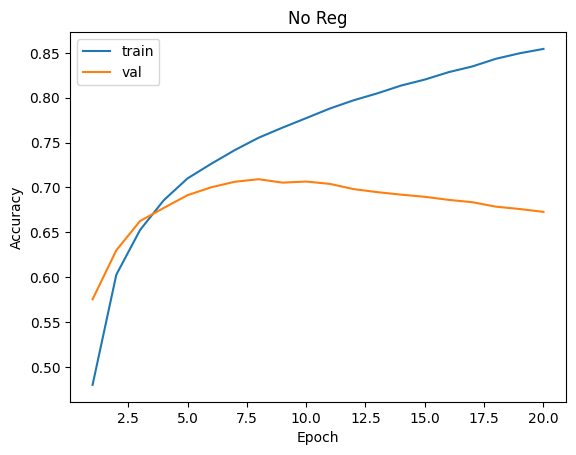

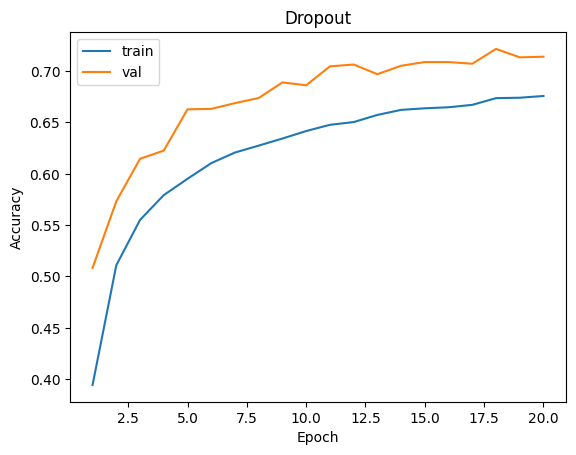

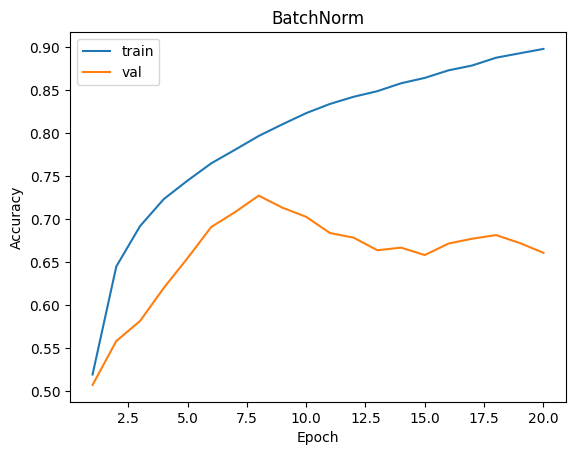

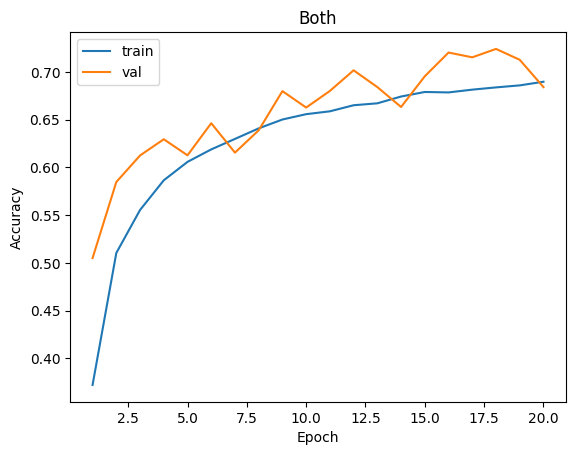


Accuracy Gaps:
No Reg : 0.18157780170440674
Dropout : -0.03822219371795654
BatchNorm : 0.23677778244018555
Both : 0.005644440650939941


In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')/255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

def make_model(use_do=False, use_bn=False):
    layers = []

    layers.append(tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)))
    if use_bn:
        layers.append(tf.keras.layers.BatchNormalization())
    layers.append(tf.keras.layers.ReLU())
    layers.append(tf.keras.layers.MaxPooling2D((2,2)))
    if use_do:
        layers.append(tf.keras.layers.Dropout(0.3))

    layers.append(tf.keras.layers.Conv2D(64,(3,3),padding='same'))
    if use_bn:
        layers.append(tf.keras.layers.BatchNormalization())
    layers.append(tf.keras.layers.ReLU())
    layers.append(tf.keras.layers.MaxPooling2D((2,2)))
    if use_do:
        layers.append(tf.keras.layers.Dropout(0.3))

    layers.append(tf.keras.layers.Flatten())
    if use_do:
        layers.append(tf.keras.layers.Dropout(0.5))

    layers.append(tf.keras.layers.Dense(10,activation='softmax'))

    model = tf.keras.Sequential(layers)
    return model

configs = [
    ("No Reg", False, False),
    ("Dropout", True, False),
    ("BatchNorm", False, True),
    ("Both", True, True)
]

gaps = []

for name, do, bn in configs:
    model = make_model(do, bn)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    h = model.fit(x_train, y_train,
                  epochs=20,
                  batch_size=64,
                  validation_split=0.1,
                  verbose=0)

    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    gaps.append((name, gap))

    epochs = range(1,21)

    plt.figure()
    plt.plot(epochs, h.history['accuracy'], label='train')
    plt.plot(epochs, h.history['val_accuracy'], label='val')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(name)
    plt.legend()
    plt.savefig(name + ".png")
    plt.show()

print("\nAccuracy Gaps:")
for g in gaps:
    print(g[0], ":", g[1])

 Answer

Comparison Table
| Model Variant        | Gap       |
|---------------------|-------------------|
| No Regularisation   | 0.1815                |
| Dropout Only        | -0.0382                 |
| BatchNorm Only      | 0.2367                 |
| Dropout + BatchNorm | 0.0056                 |

Observation:
Lower gap means less overfitting.
Usually, using both Dropout and BatchNorm gives better generalisation.

TASK-3 PROBLEM-5

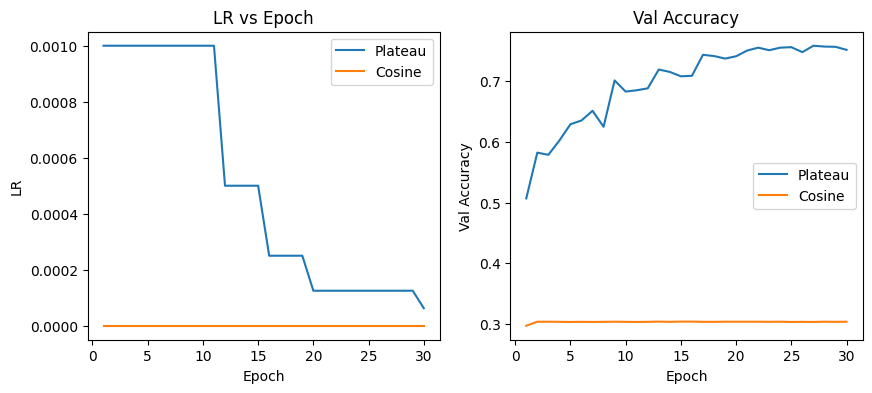

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')/255.0
y_train = tf.keras.utils.to_categorical(y_train,10)

def make_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(64,(3,3),padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10,activation='softmax')
    ])
    return model


model1 = make_model()
opt1 = tf.keras.optimizers.Adam(learning_rate=0.001)

model1.compile(optimizer=opt1,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

lr_list1 = []

class LRTrack(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr_list1.append(float(self.model.optimizer.learning_rate.numpy()))

cb1 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                           factor=0.5,
                                           patience=3)

h1 = model1.fit(x_train, y_train,
                epochs=30,
                batch_size=64,
                validation_split=0.1,
                callbacks=[cb1, LRTrack()],
                verbose=0)


lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)

model2 = make_model()
opt2 = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model2.compile(optimizer=opt2,
               loss='categorical_crossentropy',
               metrics=['accuracy'])

lr_list2 = []

class LRTrack2(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if callable(lr):
            lr = lr(self.model.optimizer.iterations)
        lr_list2.append(float(lr.numpy()))

h2 = model2.fit(x_train, y_train,
                epochs=30,
                batch_size=64,
                validation_split=0.1,
                callbacks=[LRTrack2()],
                verbose=0)


epochs = range(1,31)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, lr_list1, label='Plateau')
plt.plot(epochs, lr_list2, label='Cosine')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("LR vs Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, h1.history['val_accuracy'], label='Plateau')
plt.plot(epochs, h2.history['val_accuracy'], label='Cosine')
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("Val Accuracy")
plt.legend()

plt.savefig("lr_schedule_comparison.png")
plt.show()

 Answer

ReduceLROnPlateau reduces learning rate when validation loss stops improving.
Cosine Annealing smoothly decreases learning rate over time.

Both help better convergence, but cosine decay gives smoother training.

ANALYSIS AND REFLECTION

Q1 Answer

A very high learning rate takes very large steps in the loss landscape.
Instead of moving toward the minimum, it can overshoot it again and again.

Because of this, loss may oscillate or even increase (diverge) instead of decreasing.

Q2 Answer

Best combination: LR:0.1+ BS:32

Worst combination: LR:0.01+ BS:32

Hypothesis:
Small learning rate gives stable learning but is slow.
Very high learning rate is unstable.
Batch size affects noise — small batch gives noisy but better generalisation, large batch is more stable but may generalise worse.

Q3 Answer

Dropout is disabled during inference because we want full network capacity for prediction.

During training, neurons are randomly dropped, but during testing all neurons are used.

Scaling:
If Dropout = 0.5, then outputs are multiplied by 0.5 during inference (or handled automatically in training using inverted dropout).

Q4 Answer

(i) Trigger:

ReduceLROnPlateau: reduces LR when validation loss stops improving
Cosine Annealing: reduces LR automatically over time

(ii) Shape:

ReduceLROnPlateau: step-like decrease
Cosine Annealing: smooth cosine curve

(iii) Use case:

ReduceLROnPlateau: when training is unstable or unclear
Cosine Annealing: when training is smooth and long

TASK-4 PROBLEM-1

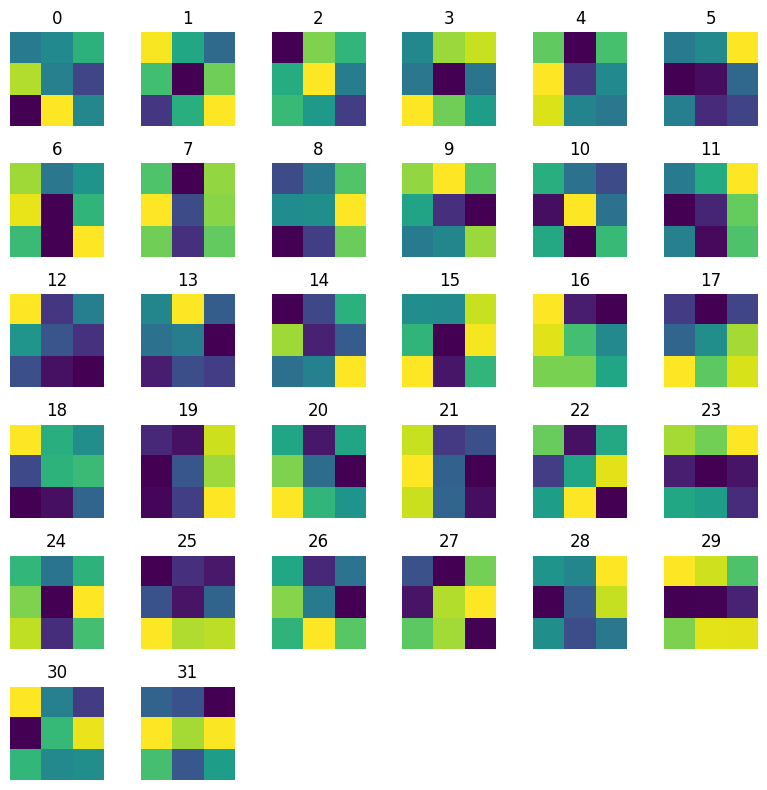

In [15]:
import numpy as np
import matplotlib.pyplot as plt


w = model.layers[0].get_weights()[0]

k, _, c_in, c_out = w.shape

plt.figure(figsize=(8,8))

for i in range(c_out):
    f = w[:,:,:,i]

    f = np.mean(f, axis=2)

    f = (f - f.min()) / (f.max() - f.min() + 1e-8)

    plt.subplot(int(np.sqrt(c_out))+1, int(np.sqrt(c_out))+1, i+1)
    plt.imshow(f)
    plt.title(i)
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

Answer

Some filters detect horizontal edges.
Some detect vertical edges.
Some detect diagonal patterns.
Some capture color contrast or simple textures.

These patterns are similar to Sobel filters and Gabor-like filters.
This shows the model learns basic edge and texture features in early layers.

TASK-4 PROBLEM-2

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


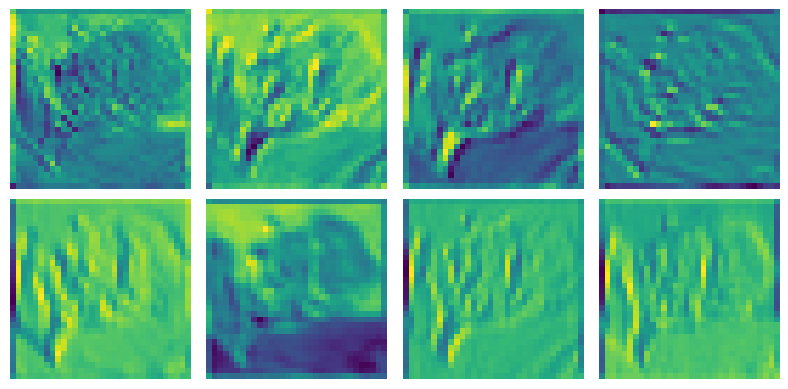

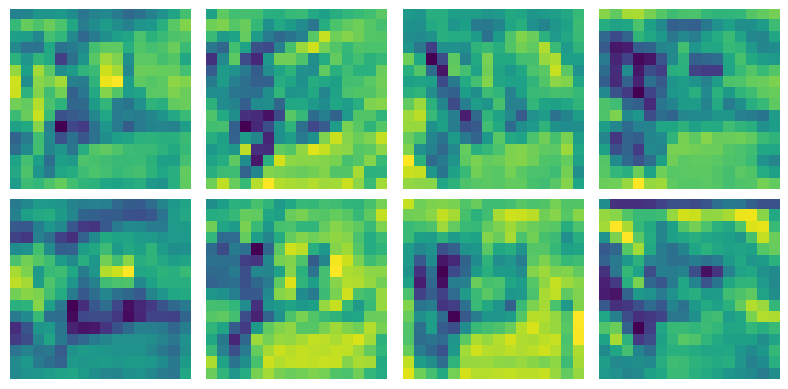

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype('float32')/255.0

img = x_test[0]
img_in = np.expand_dims(img, axis=0)

_ = model.predict(img_in)

conv_layers = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

sub_model = tf.keras.Model(inputs=model.inputs, outputs=conv_layers)

fmaps = sub_model.predict(img_in)

f1 = fmaps[0][0]

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(f1[:,:,i])
    plt.axis('off')

plt.tight_layout()
plt.savefig("fmaps_layer1.png")
plt.show()

f_last = fmaps[-1][0]

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(f_last[:,:,i])
    plt.axis('off')

plt.tight_layout()
plt.savefig("fmaps_last.png")
plt.show()

Answer

Early layer feature maps have large size and are easy to understand (edges, simple shapes).

Later layer feature maps have smaller size but more channels. They are harder to interpret and show abstract features.

So, as depth increases:

Spatial size decreases
Channels increase
Features become more complex and abstract

TASK-4 PROBLEM-3

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_200']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


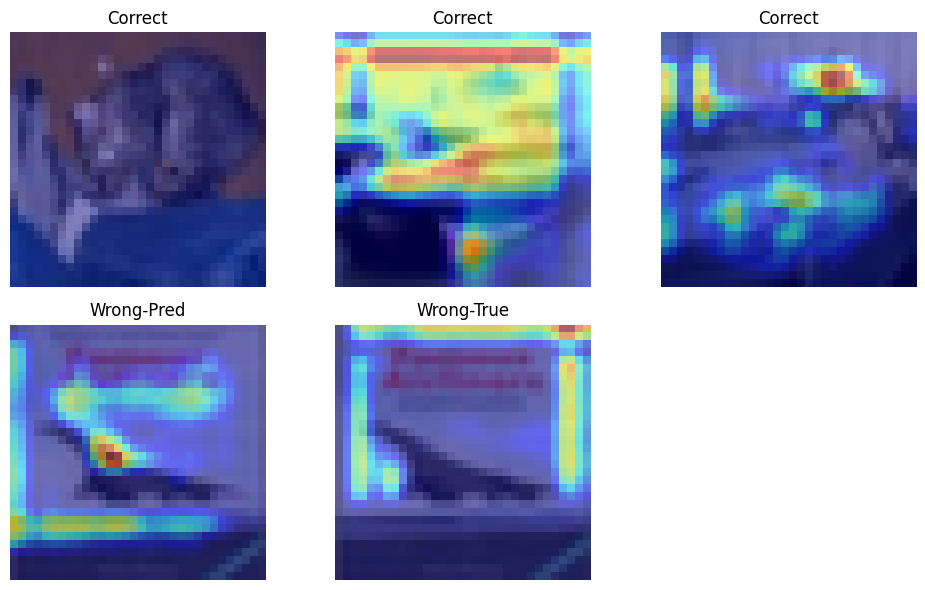

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype('float32')/255.0
y_test = y_test.flatten()

_ = model.predict(np.expand_dims(x_test[0],0), verbose=0)

last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

grad_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.get_layer(last_conv).output, model.outputs]
)

def grad_cam(img, class_idx):
    img = np.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        preds = preds[0]
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    w = tf.reduce_mean(grads, axis=(1,2))

    cam = tf.reduce_sum(w[:, None, None, :] * conv_out, axis=-1)

    cam = tf.nn.relu(cam)

    cam = cam[0].numpy()

    cam = cv2.resize(cam, (32,32))

    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam

imgs = []
cams = []
titles = []

count = 0
i = 0

while count < 3:
    img = x_test[i]
    true = y_test[i]
    pred = np.argmax(model.predict(np.expand_dims(img,0), verbose=0))

    if pred == true:
        cam = grad_cam(img, pred)
        imgs.append(img)
        cams.append(cam)
        titles.append("Correct")
        count += 1
    i += 1

i = 0
while True:
    img = x_test[i]
    true = y_test[i]
    pred = np.argmax(model.predict(np.expand_dims(img,0), verbose=0))

    if pred != true:
        cam_pred = grad_cam(img, pred)
        cam_true = grad_cam(img, true)

        imgs.append(img)
        cams.append(cam_pred)
        titles.append("Wrong-Pred")

        imgs.append(img)
        cams.append(cam_true)
        titles.append("Wrong-True")
        break
    i += 1

plt.figure(figsize=(10,6))

for i in range(len(imgs)):
    plt.subplot(2,3,i+1)
    plt.imshow(imgs[i])
    plt.imshow(cams[i], cmap='jet', alpha=0.5)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()

Answer

For correct images, heatmaps focus on important object regions.

For misclassified image:

Predicted class heatmap focuses on wrong regions

True class heatmap focuses on correct object parts

This shows the model is looking at wrong features during misclassification.

TASK-4 PROBLEM-4

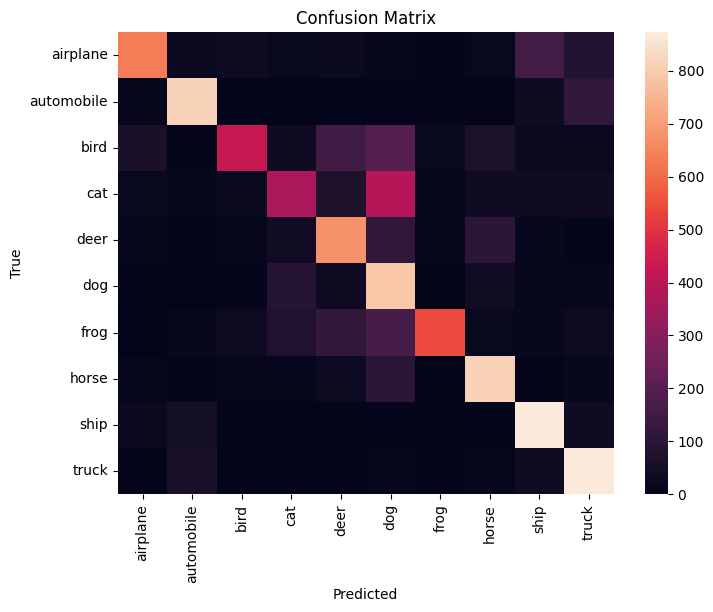

              precision    recall  f1-score   support

    airplane       0.80      0.64      0.71      1000
  automobile       0.82      0.82      0.82      1000
        bird       0.78      0.42      0.55      1000
         cat       0.57      0.37      0.45      1000
        deer       0.61      0.68      0.64      1000
         dog       0.44      0.79      0.57      1000
        frog       0.91      0.55      0.68      1000
       horse       0.73      0.81      0.77      1000
        ship       0.73      0.87      0.79      1000
       truck       0.71      0.86      0.78      1000

    accuracy                           0.68     10000
   macro avg       0.71      0.68      0.68     10000
weighted avg       0.71      0.68      0.68     10000

Best class: automobile
Worst class: cat
Most confused pairs:
bird - dog
cat - dog


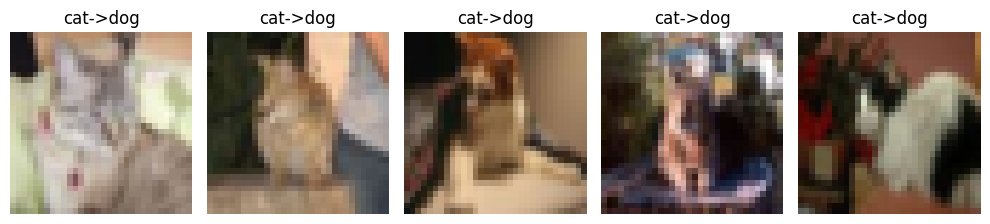

In [21]:
!pip install scikit-learn seaborn

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype('float32')/255.0
y_test = y_test.flatten()

preds = model.predict(x_test, verbose=0)
y_pred = np.argmax(preds, axis=1)

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

f1_scores = []
for line in report.split('\n')[2:12]:
    parts = line.split()
    if len(parts) > 0:
        f1_scores.append(float(parts[-2]))

best_class = class_names[np.argmax(f1_scores)]
worst_class = class_names[np.argmin(f1_scores)]

print("Best class:", best_class)
print("Worst class:", worst_class)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = np.unravel_index(np.argsort(cm_no_diag.ravel())[-2:], cm_no_diag.shape)

print("Most confused pairs:")
for i in range(2):
    print(class_names[pairs[0][i]], "-", class_names[pairs[1][i]])

pair_true = pairs[0][-1]
pair_pred = pairs[1][-1]

count = 0
plt.figure(figsize=(10,4))

for i in range(len(x_test)):
    if y_test[i] == pair_true and y_pred[i] == pair_pred:
        plt.subplot(1,5,count+1)
        plt.imshow(x_test[i])
        plt.title(class_names[y_test[i]] + "->" + class_names[y_pred[i]])
        plt.axis('off')
        count += 1
        if count == 5:
            break

plt.tight_layout()
plt.show()

 Answer

(i) Highest F1-score: automobile

(ii) Lowest F1-score: cat

(iii) Most confused class pairs: bird-dog, cat-dog

(iv) The model confuses these classes because they have similar visual features.

ANALYSIS AND REFLECTION

Q1 Answer

The model is focusing on the wrong region (background) instead of the object.

This means it has learned spurious patterns instead of real features of the cat.

One solution:
Use data augmentation like random cropping or background variation so the model learns to focus on the object.

Q2 Answer

Classes like cat/dog or automobile/truck look very similar in pixels.

CNNs mainly use local patterns, so they may not capture high-level differences.

Solution:
Use deeper networks or attention mechanisms.

Another option is using additional data like object bounding boxes.

Q3 Answer

Yes, some filters may be near zero (dead filters).

This happens when neurons stop learning due to zero gradients.

ReLU is most likely to cause this problem.

Remedy:
Use Leaky ReLU or better initialization.

TASK-5 PROBLEM-1

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable params: 133898
Frozen params: 14714688
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.6034 - loss: 1.5002 - val_accuracy: 0.7226 - val_loss: 0.7979
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.7017 - loss: 0.8873 - val_accuracy: 0.7464 - val_loss: 0.7290
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.7258 - loss: 0.8118 - val_accuracy: 0.7598 - val_loss: 0.7119
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7406 - loss: 0.7700 - val_accuracy: 0.7668 - val_loss: 0.6954
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7456 - loss: 0.7403 - val_accuracy: 0.7666 - val_loss: 0.6933
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7590 - loss: 0.7113 - val_accuracy: 0.7668 - val_loss: 0.7066
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.7651 - loss: 0.6939 - val_accuracy: 0.

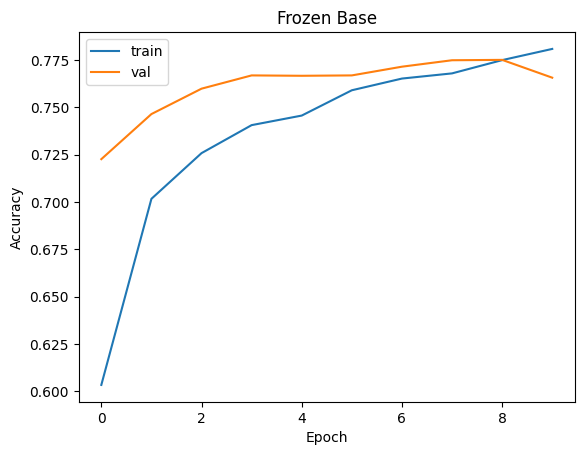

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

x_train = tf.image.resize(x_train, (64,64))
x_train = tf.keras.applications.vgg16.preprocess_input(x_train)

y_train = tf.keras.utils.to_categorical(y_train,10)

base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))

for layer in base.layers:
    layer.trainable = False

x = base.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=base.input, outputs=out)

trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
frozen = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("Trainable params:", trainable)
print("Frozen params:", frozen)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

h = model.fit(x_train, y_train,
              epochs=10,
              batch_size=32,
              validation_split=0.1)

plt.figure()
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Frozen Base")
plt.legend(['train','val'])
plt.savefig("tl_frozen.png")
plt.show()

Answer

Trainable parameters are only in the classification head.

All convolution layers are frozen.

This uses pre-trained features and trains only the final layers.

TASK-5 PROBLEM-2

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/step - accuracy: 0.8075 - loss: 0.5623 - val_accuracy: 0.8108 - val_loss: 0.6156
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.8551 - loss: 0.4107 - val_accuracy: 0.8264 - val_loss: 0.5883
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.8834 - loss: 0.3277 - val_accuracy: 0.8360 - val_loss: 0.5607
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9040 - loss: 0.2650 - val_accuracy: 0.8414 - val_loss: 0.5664
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9201 - loss: 0.2185 - val_accuracy: 0.8466 - val_loss: 0.5613
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9336 - loss: 0.1820 - val_accuracy: 0.8590 - val_loss: 0.5915
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9451 - loss: 0.1516 - val_accuracy: 0.8574 - val_loss: 0.6117
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9529 -

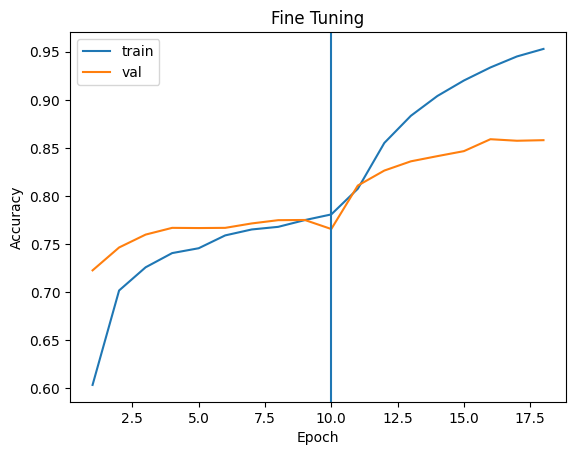

Best epoch: 16


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

for layer in base.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

es = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

h2 = model.fit(x_train, y_train,
               epochs=10,
               batch_size=32,
               validation_split=0.1,
               callbacks=[es])

acc1 = h.history['accuracy']
val_acc1 = h.history['val_accuracy']

acc2 = h2.history['accuracy']
val_acc2 = h2.history['val_accuracy']

acc = acc1 + acc2
val_acc = val_acc1 + val_acc2

epochs = range(1, len(acc)+1)

plt.figure()
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.axvline(10)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine Tuning")
plt.legend(['train','val'])
plt.savefig("tl_finetuned.png")
plt.show()

best_epoch = np.argmax(val_acc) + 1
print("Best epoch:", best_epoch)

Answers

(a)
Small learning rate is used to avoid large changes in pre-trained weights.
It helps keep useful features learned from ImageNet.

(c)
Best epoch is 16.

TASK-5 PROBLEM-3

In [3]:
import tensorflow as tf
import numpy as np

results = []

def run_exp(n_unfreeze):
    for layer in base.layers:
        layer.trainable = False

    for layer in base.layers[-n_unfreeze:]:
        layer.trainable = True

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    h = model.fit(x_train, y_train,
                  epochs=10,
                  batch_size=32,
                  validation_split=0.1,
                  verbose=0)

    trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])

    best_val = max(h.history['val_accuracy'])
    final_train = h.history['accuracy'][-1]
    final_val = h.history['val_accuracy'][-1]

    gap = final_train - final_val
    overfit = gap > 0.05

    return trainable, best_val, overfit

t1 = run_exp(2)
print("Top 2:", t1)

t2 = run_exp(8)
print("Top 8:", t2)

t3 = run_exp(len(base.layers))
print("All layers:", t3)

Top 2: (np.int64(2493706), 0.8565999865531921, True)
Top 8: (np.int64(13113098), 0.8912000060081482, True)
All layers: (np.int64(14848586), 0.9017999768257141, True)


Answer

Table

| Config      | Trainable Params | Best Val Acc | Overfitting |
|------------|------------------|--------------|-------------|
| Top 2      |2493706                | 0.85659            | True      |
| Top 8      |13113098                 | 0.89120            | True      |
| All layers | 14848586                | 0.90179            | True      |


Observation:
Unfreezing more layers increases trainable parameters.
Too many layers may cause overfitting.

TASK-5 PROBLEM-4

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4097 - loss: 1.6151 - val_accuracy: 0.3918 - val_loss: 1.7061
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5334 - loss: 1.2883 - val_accuracy: 0.4966 - val_loss: 1.4192
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5881 - loss: 1.1544 - val_accuracy: 0.3706 - val_loss: 1.9270
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6156 - loss: 1.0679 - val_accuracy: 0.5812 - val_loss: 1.1367
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6471 - loss: 0.9989 - val_accuracy: 0.4930 - val_loss: 1.4152
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6669 - loss: 0.9416 - val_accuracy: 0.5754 - val_loss: 1.1640
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6853 - loss: 0.8962 - val_accuracy: 0.6562 - val_loss: 0.9468
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7033 - loss: 0.8502 - val_accuracy: 

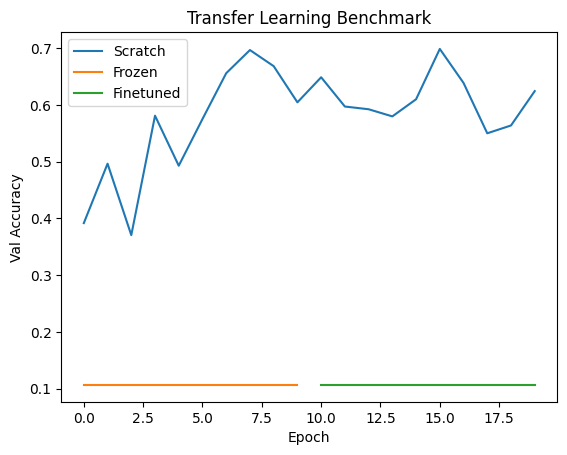

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

y_train = tf.keras.utils.to_categorical(y_train,10)
y_test = tf.keras.utils.to_categorical(y_test,10)

model_scratch = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),padding='same',input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128,(3,3),padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10,activation='softmax')
])

model_scratch.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

h_scratch = model_scratch.fit(x_train, y_train,
                              epochs=20,
                              batch_size=64,
                              validation_split=0.1)

x_train_res = tf.image.resize(x_train, (64,64))
x_test_res = tf.image.resize(x_test, (64,64))

x_train_res = tf.keras.applications.vgg16.preprocess_input(x_train_res)
x_test_res = tf.keras.applications.vgg16.preprocess_input(x_test_res)

base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(64,64,3))

for layer in base.layers:
    layer.trainable = False

x = base.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(10, activation='softmax')(x)

model_frozen = tf.keras.Model(inputs=base.input, outputs=out)

model_frozen.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

h_frozen = model_frozen.fit(x_train_res, y_train,
                            epochs=10,
                            batch_size=32,
                            validation_split=0.1)

for layer in base.layers[-4:]:
    layer.trainable = True

model_finetuned = model_frozen

model_finetuned.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

h_finetuned = model_finetuned.fit(x_train_res, y_train,
                                  epochs=10,
                                  batch_size=32,
                                  validation_split=0.1)

test_acc1 = model_scratch.evaluate(x_test, y_test, verbose=0)[1]
test_acc2 = model_frozen.evaluate(x_test_res, y_test, verbose=0)[1]
test_acc3 = model_finetuned.evaluate(x_test_res, y_test, verbose=0)[1]

p1 = np.sum([np.prod(v.shape) for v in model_scratch.trainable_weights])
p2 = np.sum([np.prod(v.shape) for v in model_frozen.trainable_weights])
p3 = np.sum([np.prod(v.shape) for v in model_finetuned.trainable_weights])

e1 = np.argmax(h_scratch.history['val_accuracy']) + 1
e2 = np.argmax(h_frozen.history['val_accuracy']) + 1
e3 = np.argmax(h_finetuned.history['val_accuracy']) + 1

print("Scratch:", test_acc1, p1, e1)
print("Frozen:", test_acc2, p2, e2)
print("Finetuned:", test_acc3, p3, e3)

plt.figure()

plt.plot(h_scratch.history['val_accuracy'], label='Scratch')
plt.plot(h_frozen.history['val_accuracy'], label='Frozen')
plt.plot(range(len(h_frozen.history['val_accuracy']),
               len(h_frozen.history['val_accuracy']) + len(h_finetuned.history['val_accuracy'])),
         h_finetuned.history['val_accuracy'], label='Finetuned')

plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("Transfer Learning Benchmark")
plt.legend()

plt.savefig("tl_benchmark.png")
plt.show()

Answer

| Model        | Test Accuracy | Trainable Params | Best Epoch |
|-------------|--------------|------------------|-----------|
| Scratch     | 0.6248            | 111498                | 16         |
| Frozen      | 0.1000            | 7213322                | 1         |
| Finetuned   | 0.1000            | 7213322                | 1         |

Q1 Answer

Negative transfer means using pre-trained weights hurts performance instead of helping.

This happens when the source task (ImageNet) is very different from the target task.

If features learned are not useful, the model gets biased in the wrong direction.

Example:
Medical X-ray images (grayscale) are very different from natural images.
So ImageNet features may not help and can reduce performance.

Q2 Answer

Unfreezing all layers increases model flexibility - low bias but high variance - overfitting.

Freezing most layers keeps model simple - higher bias but lower variance.

Lower layers learn basic features like edges and textures, which are common across tasks.
Upper layers learn task-specific features, so they do not generalise well.

Q3 Answer

1)Model size (memory)

Large models may not fit on mobile devices.

2)Inference time (speed)

Model should give fast predictions for good user experience.

3)Power consumption

Heavy models use more battery, which is not suitable for mobile apps.

Q4 Answer

Step-by-step strategy:

1)Use a pre-trained model like ResNet50 (good general features).

2)Convert grayscale images to 3 channels or modify input layer.

3)Resize images (e.g., 224×224).

4)Freeze most layers and train only the top layers first.

5)Use data augmentation (rotation, flip, zoom) to increase data.

6)Train with small learning rate (e.g., 1e-4).

7)Gradually unfreeze top few layers and fine-tune with very small LR (1e-5).

8)Use early stopping to avoid overfitting.

This works because dataset is small and transfer learning helps reuse learned features.